<a href="https://colab.research.google.com/github/ManishSahani24/Quantum-Error-Correction/blob/main/Quantum_Error_Correction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Encoding Qubits

The 3-bit repetition code is a classical error correcting code, but we can consider what happens if we try to use it to protect qubits against errors. As we'll see, it's not a very impressive quantum error correcting code, because it actually makes some errors more likely.

$$$$

In classical computing, if you want to protect a bit against accidental flips (like a $0$ turning into a $1$ due to noise), you can just copy it. You encode a $0$ as $000$ and a $1$ as $111$. If an error changes $000$ to $010$, you can take a "majority vote" and easily correct it back to $000$.

$$$$

However, in quantum computing, the No-Cloning Theorem says that you cannot create an identical copy of an arbitrary unknown quantum state. Therefore, if you have a qubit in a superposition $\alpha|0\rangle + \beta|1\rangle$,

you cannot just clone it to make:

 $(\alpha|0\rangle + \beta|1\rangle) \otimes (\alpha|0\rangle + \beta|1\rangle) \otimes (\alpha|0\rangle + \beta|1\rangle)$.

$$$$



 ---------------------------------------

 #### The Solution: Encoding the Basis States

  Instead of cloning the entire superposition, we apply the repetition code strictly to the standard basis states $|0\rangle$ and $|1\rangle$.

  * The logical zero state ($|0\rangle_L$) is encoded as the physical state $|000\rangle$.
  * The logical one state ($|1\rangle_L$) is encoded as the physical state $|111\rangle$.

$$$$


By spreading the information of one logical qubit across three physical qubits, you protect it against a single bit-flip error (an X-gate error).


To be clear, when we refer to the 3-bit repetition code being used for qubits, we have in mind an encoding of a qubit where **standard basis states are repeated three times**, so that a single-qubit state vector is encoded as follows.

$$\alpha|0\rangle+\beta|1\rangle\mapsto\alpha|000\rangle+\beta|111\rangle$$

This encoding can easily be achieved by the following quantum circuit.

> This is the new, 3-qubit encoded state. The original probability amplitudes ($\alpha$ and $\beta$) are perfectly preserved. However, instead of weighting single-qubit states, they now weight the 3-qubit entangled states $|000\rangle$ and $|111\rangle$.

$$$$

###### Physical Qubits ( HARDWARE )

1. A physical qubit is an actual, tangible piece of hardware in a quantum computer—like a single superconducting circuit, a trapped ion, or a single photon.

2. The problem with physical qubits is that they are extremely fragile. They are easily affected by heat, electromagnetic radiation, or slight calibration errors, which causes them to randomly flip or lose their state (decoherence).


###### Logical Qubits ( SOFTWARE )

1. A logical qubit is an abstract, idealized, mathematically perfect qubit. When we write a quantum algorithm (like Shor's algorithm), we are writing it under the assumption that our qubits are perfect and error-free.

2. Because we don't have perfect physical qubits, we have to build one logical qubit by grouping together many physical qubits.

3. Whenever the quantum algorithm asks for one perfect, error-free 'Zero' ($|0\rangle_L$), we are going to represent that in the real world using three actual physical qubits, all set to zero ($|000\rangle$).






### Entanglement is not cloning

Here we are not cloning the qubit. What we are doing in quantum error correction is creating an entangled state, not a cloned state. In the state $\alpha|000\rangle + \beta|111\rangle$, the three physical qubits are inextricably linked. The information about $\alpha$ and $\beta$ is spread out globally across the entanglement of all three qubits, rather than existing independently on each individual qubit.

In [2]:
!pip install -q qiskit
!pip install -q qiskit_ibm_runtime
!pip install -q qiskit_aer
!pip install -q matplotlib numpy pylatexenc -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 86.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.8/386.8 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.8/212.8 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 106.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [3]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_state_qsphere
import numpy as np
import matplotlib.pyplot as plt
import qiskit, qiskit_ibm_runtime, qiskit_aer

/usr/local/lib/python3.12/dist-packages/samplomatic/__init__.py:20: UserWarning: 
You have imported samplomatic==0.18.0 which is in 
beta development. Please expect breaking changes between 
minor versions and pin your dependencies accordingly.
  _warn_once_per_version(


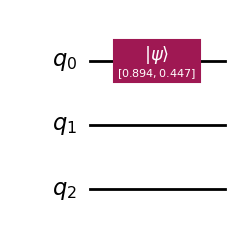

In [4]:
#Initialization of three quantum states

qc = QuantumCircuit(3)

# 2. Define arbitrary probabilities for our initial state
# Let's say alpha gives an 80% chance of 0, and beta gives a 20% chance of 1

alpha = np.sqrt(0.8)
beta = np.sqrt(0.2)

qc.initialize([alpha, beta], 0)
#qc.barrier()

qc.draw('mpl')


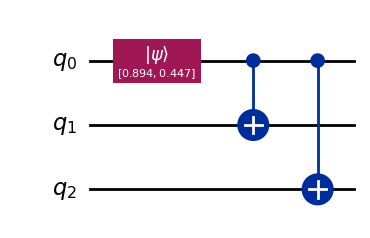

In [5]:
#applying the CNOT gate

qc.cx(0,1)
qc.cx(0,2)

qc.draw('mpl')

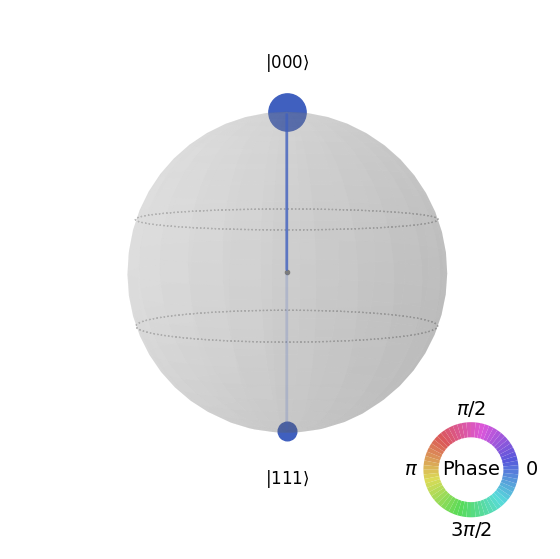

In [6]:
sv = Statevector(qc)
plot_state_qsphere(sv)


* We will notice that the final output vector only has non-zero values for the $|000\rangle$ and $|111\rangle$ states, and those values will perfectly match the $\alpha$ and $\beta$ we defined at the start.

* The initial unknown state of the single data qubit has been successfully stretched out to entangle all three physical qubits. The encoding is complete.


In [7]:
print(state.draw('text'))

NameError: name 'state' is not defined

### Bit Flip Error

We have the encoded entangled state: $\alpha|000\rangle + \beta|111\rangle$.

let's suppose that an
X gate, or in other words a bit-flip, occurs on one of the qubits. For instance, if the middle qubit experiences a bit-flip, the state of the three qubits is transformed into this state:

The new, corrupted state is: $\alpha|010\rangle + \beta|101\rangle$

By just looking at the mathematical expression, we can easily see the middle digit is the odd one out in both terms. But the quantum computer doesn't "see" the math; it just holds the physical qubits.

$$$$

* In quantum mechanics, we run into the problem of measurement collapse.

* If we try to measure the three qubits directly in the standard basis to see where the error is, the superposition instantly collapses.

* We will see $010$ with a probability of $|\alpha|^2$.

* Or, we will see $101$ with a probability of $|\beta|^2$.

* Congratulations, we now know the middle bit flipped! But tragically, we have completely destroyed the $\alpha$ and $\beta$ superposition. The quantum information we were trying to protect is gone forever. Measuring the state directly is fatal to the algorithm.



#### Parity Measurement

1. Instead of asking, "What state are these qubits in?" (which causes a collapse), we ask, "Do these qubits have the same value or different values?" This is called measuring parity.

2. By measuring the parity between the top two qubits, and then the bottom two qubits, we can deduce exactly which qubit flipped without ever learning if the system is secretly leaning towards $|000\rangle$ or $|111\rangle$. This allows us to apply a correction gate while keeping the delicate $\alpha$ and $\beta$ amplitudes perfectly intact.



#### The syndrome measurement circuit

***The Architecture of the Circuit***

The circuit uses five total qubits, split into two groups:

* The Top 3 Wires (Data Qubits): These hold your encoded state ($\alpha|000\rangle + \beta|111\rangle$). We will call them $D_0, D_1,$ and $D_2$ from top to bottom.

* The Bottom 2 Wires (Ancilla Qubits): These are fresh "workspace" qubits initialized to $|0\rangle$. They act as our parity checkers. We will call them $A_0$ and $A_1$.



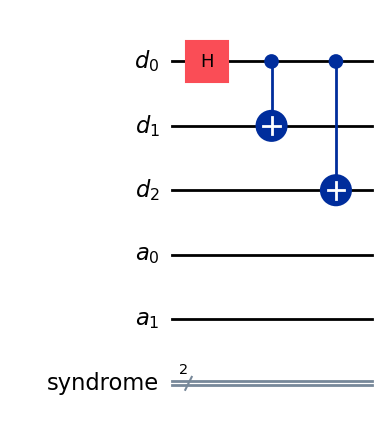

In [8]:
data = QuantumRegister(3, name='d')
ancilla = QuantumRegister(2, name='a')
syndrome = ClassicalRegister(2, name='syndrome')

qc = QuantumCircuit(data, ancilla, syndrome)

qc.h(data[0])
# Encode it across all 3 data qubits
qc.cx(data[0], data[1])
qc.cx(data[0], data[2])


qc.draw('mpl')



### Case 1: When there is no Error during the transmission of Quantum Information

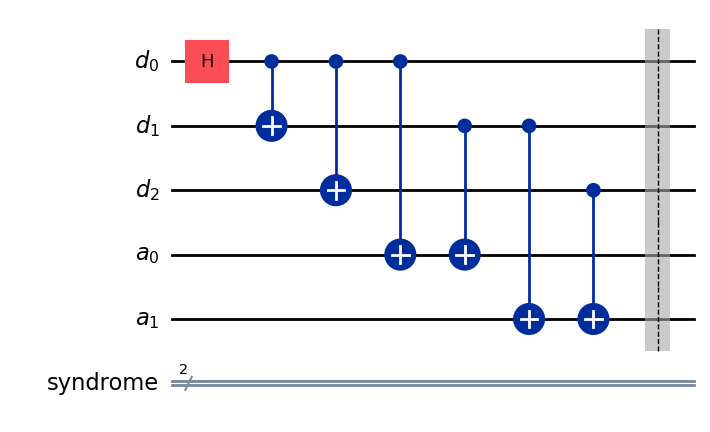

In [9]:
# --- SYNDROME MEASUREMENT
# Ancilla 0 checks parity of Data 0 and Data 1

qc.cx(data[0], ancilla[0])
qc.cx(data[1], ancilla[0])

# Ancilla 1 checks parity of Data 1 and Data 2
qc.cx(data[1], ancilla[1])
qc.cx(data[2], ancilla[1])
qc.barrier()
qc.draw('mpl')

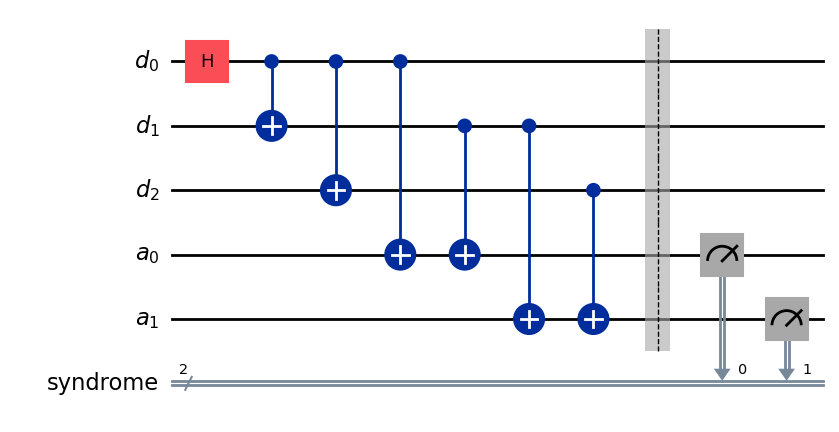

In [10]:
qc.measure(ancilla, syndrome)
qc.draw('mpl')

--- Syndrome Measurement Circuit ---


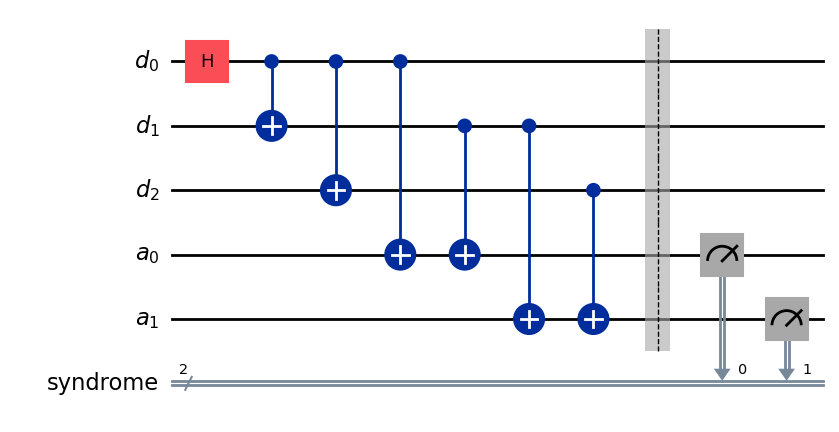

In [19]:
from qiskit_aer import AerSimulator
simulator = AerSimulator()
result = simulator.run(qc, shots=1).result()
counts = result.get_counts(qc)

# Print the circuit and the measured syndrome
print("--- Syndrome Measurement Circuit ---")
qc.draw('mpl')

In [12]:
print("--- Results ---")
# The output format for Qiskit counts is 'A1 A0'
measured_syndrome = list(counts.keys())[0]
print(f"Measured Syndrome (A1 A0): {measured_syndrome}")

print(f"The raw counts dictionary looks like this: {counts}")
print(f"The actual measured value is: {measured_syndrome}")


--- Results ---
Measured Syndrome (A1 A0): 00
The raw counts dictionary looks like this: {'00': 1}
The actual measured value is: 00


The actual measured value $"00"$, means that there is no error the qubit has undergone during the transmission. parity is perfectly matched and no correction is needed

### Case 2: When there is a bit flip error occured in the $d_0$ qubit

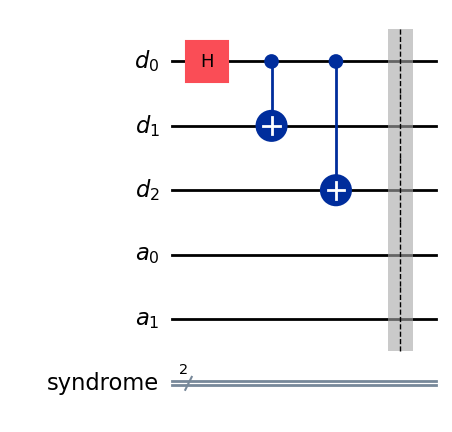

In [13]:
data = QuantumRegister(3, name='d')
ancilla = QuantumRegister(2, name='a')
syndrome = ClassicalRegister(2, name='syndrome')

qc3 = QuantumCircuit(data, ancilla, syndrome)

qc3.h(data[0])
# Encode it across all 3 data qubits
qc3.cx(data[0], data[1])
qc3.cx(data[0], data[2])
qc3.barrier()

qc3.draw('mpl')

In [14]:
print("Injecting an X error on the top data qubit (d_0)...")
qc3.x(data[0])
qc3.barrier()

Injecting an X error on the top data qubit (d_0)...


CircuitInstruction(operation=Instruction(name='barrier', num_qubits=5, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "d"), index=0>, <Qubit register=(3, "d"), index=1>, <Qubit register=(3, "d"), index=2>, <Qubit register=(2, "a"), index=0>, <Qubit register=(2, "a"), index=1>), clbits=())

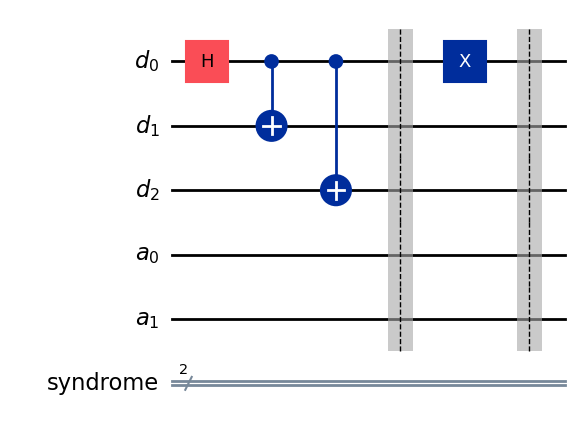

In [15]:
qc3.draw('mpl')

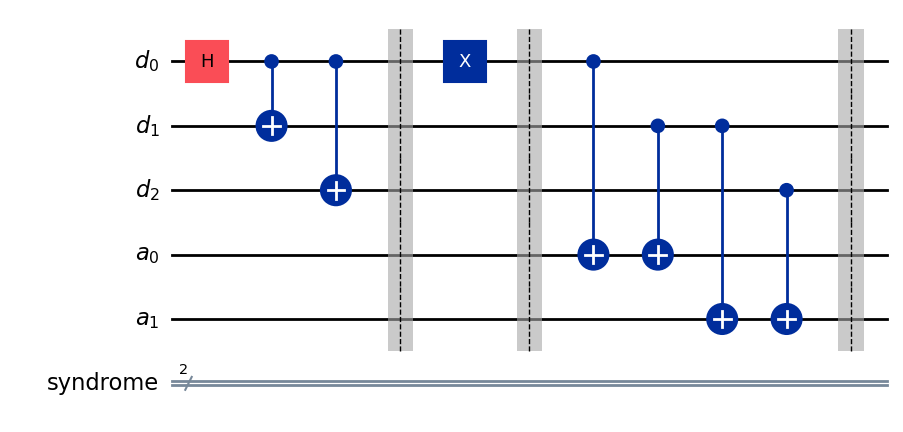

In [16]:
# --- SYNDROME MEASUREMENT ---
qc3.cx(data[0], ancilla[0])
qc3.cx(data[1], ancilla[0])

qc3.cx(data[1], ancilla[1])
qc3.cx(data[2], ancilla[1])
qc3.barrier()

qc3.draw('mpl')

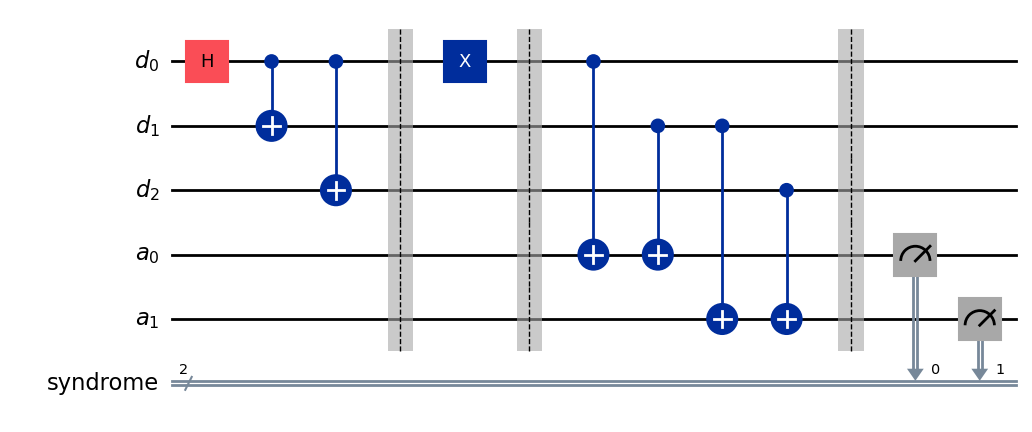

In [17]:
qc3.measure(ancilla, syndrome)
qc3.draw('mpl')

In [18]:
simulator = AerSimulator()
result = simulator.run(qc3, shots=1).result()
counts = result.get_counts(qc3)

print("--- Diagnostic Results ---")
measured_syndrome = list(counts.keys())[0]
print(f"Measured Syndrome (A1 A0): {measured_syndrome}")


--- Diagnostic Results ---
Measured Syndrome (A1 A0): 01


* $a_0$ checks the parity of $d_0$ and $d_1$. Since they are different, one of the qubit among $d_0$ or $d_1$ would have flipped.

* $a_1$ checks the parity of $d_1$ and $d_2$. The measurement of $a_1$ is $0$, this implies there is no bit flip between $d_1$ and $d_2$.

**From here, it can be concluded that bit flip occured in $d_0$ qubit.**

$$$$

>> We are only considering the possibility that at most one bit-flip occurred. This wouldn't work correctly if two or three bit-flips occurred